# DBSCAN Clustering Analysis for Lung Cancer Dataset

**Goal:** Analyze if our 4 cancer types (adenocarcinoma, large cell carcinoma, squamous cell carcinoma, normal) naturally cluster together based on visual features.

**Method:** Use DBSCAN clustering on image features extracted by ResNet50.

In [96]:
import sys
from pathlib import Path

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent))

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from PIL import Image
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import TSNE
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA 
from sklearn.neighbors import NearestNeighbors

from common.constants.datasets_constants import DatasetConstants

## Step 1: Configuration

Set up paths and DBSCAN parameters.

In [106]:
class VariantDBSCAN:
    """DBSCAN clustering analysis for lung cancer image dataset."""
    
    def __init__(self, dataset_dir=DatasetConstants.UNIFIED_DATASET_DIR, eps=30, min_samples=5):
        self.dataset_dir = Path(dataset_dir)
        self.eps = eps
        self.min_samples = min_samples
        self.feature_extractor = tf.keras.applications.ResNet50(
            weights='imagenet', 
            include_top=False, 
            pooling='avg'
        )
        print(f"Initialized DBSCAN with eps={self.eps}, min_samples={self.min_samples}")
    
    def extract_features(self, dataset):
        features_list, labels_list = [], []
        
        for images, batch_labels in dataset:
            preprocessed = tf.keras.applications.resnet50.preprocess_input(images)
            features_list.append(self.feature_extractor(preprocessed, training=False).numpy())
            labels_list.append(batch_labels.numpy().argmax(axis=1))
        
        features = np.vstack(features_list)
        labels = np.concatenate(labels_list)
        print(f"Extracted {features.shape[0]} samples with {features.shape[1]} features")
        
        return features, labels
    
    def apply_dbscan(self, features, labels, class_names):
        # 1. Scaling & PCA
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
        
        pca = PCA(n_components=0.95) 
        features_pca = pca.fit_transform(features_scaled)
        
        print(f"PCA reduced dimensions from {features.shape[1]} to {features_pca.shape[1]}")

        # 2. חישוב המרחק לשכן ה-k (מותאם לפרמטר של המודל)
        k = self.min_samples 
        nbrs = NearestNeighbors(n_neighbors=k).fit(features_pca)
        distances, indices = nbrs.kneighbors(features_pca)

        # 3. ציור הגרף למציאת ה-EPS
        distance_desc = sorted(distances[:, k-1])
        plt.figure(figsize=(10, 6))
        plt.plot(distance_desc)
        plt.title(f'K-distance Graph (k={k})')
        plt.ylabel('Distance (Eps value)')
        plt.xlabel('Points sorted by distance')
        plt.grid(True)
        plt.show() # התוכנית תעצור כאן כדי שתסתכל על הגרף

        
        print(f"Running DBSCAN with eps={self.eps}, min_samples={self.min_samples}...")
        cluster_labels = DBSCAN(eps=self.eps, min_samples=self.min_samples).fit_predict(features_pca)
        
        # 4. ניתוח תוצאות
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        # תיקון קריטי: חישוב Silhouette על ה-PCA ולא על המקורי
        silhouette = silhouette_score(features_pca, cluster_labels) if n_clusters >= 2 else None
        
        sil_str = f"{silhouette:.3f}" if silhouette is not None else "N/A"
        print(f"Clusters: {n_clusters} | Noise: {n_noise} | Silhouette: {sil_str}")
        
        return cluster_labels, {
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette,
            'scaled_features': features_pca # מחזירים את ה-PCA לצורך ויזואליזציה מהירה
        }
    
    def calculate_clustering_accuracy(self, cluster_labels, true_labels, class_names):
        from scipy.optimize import linear_sum_assignment
        
        unique_clusters = [c for c in set(cluster_labels) if c != -1]
        n_clusters = len(unique_clusters)
        n_classes = len(class_names)
        
        confusion = np.zeros((n_clusters, n_classes), dtype=int)
        for cluster_idx, cluster_id in enumerate(unique_clusters):
            mask = cluster_labels == cluster_id
            for class_idx in range(n_classes):
                confusion[cluster_idx, class_idx] = np.sum(true_labels[mask] == class_idx)
        
        row_ind, col_ind = linear_sum_assignment(-confusion)
        correct = confusion[row_ind, col_ind].sum()
        n_noise = np.sum(cluster_labels == -1)
        total = len(cluster_labels)
        accuracy = correct / total
        
        mapping = {
            unique_clusters[cluster_idx]: class_names[class_idx] 
            for cluster_idx, class_idx in zip(row_ind, col_ind)
        }
        
        print(f"\n{'='*60}")
        print(f"CLUSTERING ACCURACY ANALYSIS")
        print(f"{'='*60}")
        print(f"\nOverall Accuracy: {accuracy:.2%} ({correct}/{total} correct)")
        print(f"Noise points: {n_noise} ({n_noise/total:.1%})")
        
        print(f"\nCluster to Class Mapping (Hungarian Algorithm):")
        print(f"{'-'*60}")
        for cluster_idx, class_idx in zip(row_ind, col_ind):
            cluster_id = unique_clusters[cluster_idx]
            class_name = class_names[class_idx]
            cluster_size = np.sum(cluster_labels == cluster_id)
            correct_in_cluster = confusion[cluster_idx, class_idx]
            print(f"  Cluster {cluster_id:2d} → {class_name:25s} "
                  f"({correct_in_cluster:3d}/{cluster_size:3d} = {correct_in_cluster/cluster_size:.1%})")
        
        print(f"\nConfusion Matrix (Clusters vs Classes):")
        print(f"{'-'*60}")
        header = "Cluster |" + "".join([f" {name[:8]:>8s}" for name in class_names])
        print(header)
        print("-" * len(header))
        for cluster_idx, cluster_id in enumerate(unique_clusters):
            row = f"   {cluster_id:2d}   |"
            for class_idx in range(n_classes):
                row += f" {confusion[cluster_idx, class_idx]:8d}"
            print(row)
        print(f"{'='*60}\n")
        
        return accuracy, mapping
    
    def visualize_clusters(self, features_scaled, cluster_labels, true_labels, class_names):
        from sklearn.manifold import TSNE
        
        print("Running t-SNE...")
        features_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(features_scaled)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot 1: DBSCAN clusters
        unique_clusters = set(cluster_labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
        
        for idx, cluster_id in enumerate(sorted(unique_clusters)):
            mask = cluster_labels == cluster_id
            label = f"Noise ({np.sum(mask)})" if cluster_id == -1 else f"Cluster {cluster_id} ({np.sum(mask)})"
            ax1.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                       c=[colors[idx]], label=label, alpha=0.6, s=50)
        
        ax1.set_title('DBSCAN Clustering', fontsize=14, fontweight='bold')
        ax1.set_xlabel('t-SNE Component 1')
        ax1.set_ylabel('t-SNE Component 2')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: True labels
        colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
        
        for class_idx, class_name in enumerate(class_names):
            mask = true_labels == class_idx
            ax2.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                       c=[colors[class_idx]], label=f"{class_name} ({np.sum(mask)})", 
                       alpha=0.6, s=50)
        
        ax2.set_title('True Labels', fontsize=14, fontweight='bold')
        ax2.set_xlabel('t-SNE Component 1')
        ax2.set_ylabel('t-SNE Component 2')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        print("Visualization complete!")
    
    def tune_parameters(self, features, labels, class_names, 
                       eps_values=[0.3, 0.5, 0.7, 1.0, 1.5, 2.0], 
                       min_samples_values=[3, 5, 10, 15, 20]):
        from scipy.optimize import linear_sum_assignment
        
        print(f"Testing {len(eps_values) * len(min_samples_values)} combinations...")
        
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
        
        all_results = []
        best_score = -1
        best_params = None
        
        for eps in eps_values:
            for min_samples in min_samples_values:
                cluster_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(features_scaled)
                
                n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
                n_noise = list(cluster_labels).count(-1)
                silhouette = silhouette_score(features_scaled, cluster_labels) if n_clusters >= 2 else None
                
                accuracy = 0
                if n_clusters > 0:
                    unique_clusters = [c for c in set(cluster_labels) if c != -1]
                    confusion = np.zeros((n_clusters, len(class_names)), dtype=int)
                    
                    for cluster_idx, cluster_id in enumerate(unique_clusters):
                        for class_idx in range(len(class_names)):
                            confusion[cluster_idx, class_idx] = np.sum(labels[cluster_labels == cluster_id] == class_idx)
                    
                    row_ind, col_ind = linear_sum_assignment(-confusion)
                    accuracy = confusion[row_ind, col_ind].sum() / len(labels)
                
                score = accuracy + (silhouette * 0.1 if silhouette else 0) - (n_noise / len(labels)) * 0.2
                
                result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters,
                    'n_noise': n_noise,
                    'silhouette': silhouette,
                    'accuracy': accuracy,
                    'score': score
                }
                all_results.append(result)
                
                if score > best_score:
                    best_score = score
                    best_params = result
        
        print(f"✅ Best: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
        print(f"   → Accuracy: {best_params['accuracy']:.2%} | Clusters: {best_params['n_clusters']} | Noise: {best_params['n_noise']}")
        
        return best_params, all_results

analyzer = VariantDBSCAN()
print("Ready!")

Initialized DBSCAN with eps=30, min_samples=5
Ready!


## Step 2: Load Dataset

Use the `load_dataset()` utility to load the unified dataset. This gives us access to all images organized by cancer type.

In [ ]:
from ClassificationModel.src.utils.dataset_utils import load_dataset

# Load the dataset (train, validation, test splits)
dataset_dict = load_dataset()

# Display dataset info
print(f"\nDataset loaded successfully!")
print(f"Class names: {dataset_dict[DatasetConstants.CLASS_NAMES_KEY]}")
print(f"Number of classes: {dataset_dict[DatasetConstants.NUM_CLASSES_KEY]}")
print(f"\nSplits available: train, validation, test")

## Step 3: Extract Features

Extract ResNet50 features from the training dataset. This converts each image into a 2048-dimensional vector.

In [94]:
# Step 3: Extract features from training data
train_features, train_labels = analyzer.extract_features(dataset_dict[DatasetConstants.TRAIN_SPLIT_NAME])

Extracted 1013 samples with 2048 features


## Step 4: Apply DBSCAN Clustering

Now let's apply DBSCAN to see if the cancer types naturally cluster together based on their visual features.

PCA reduced dimensions from 2048 to 224


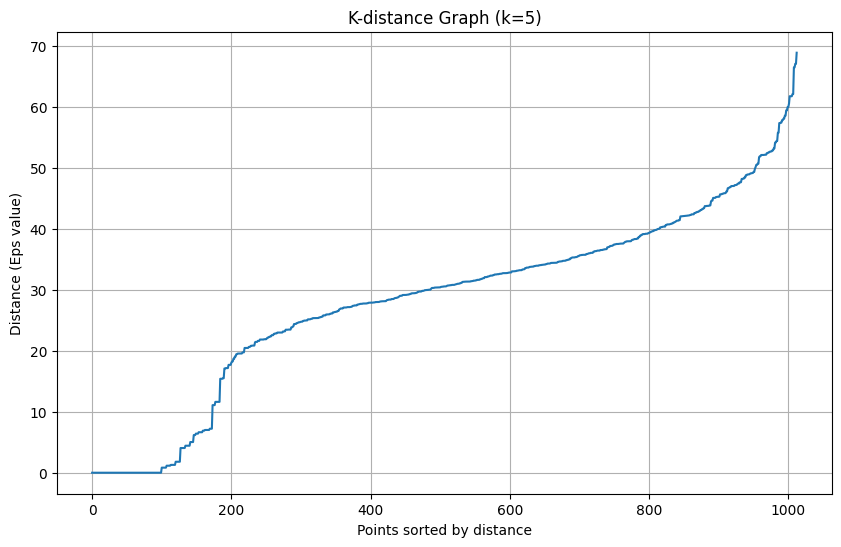

Running DBSCAN with eps=30, min_samples=5...
Clusters: 34 | Noise: 437 | Silhouette: 0.098


In [107]:
# Step 4: Apply DBSCAN with default parameters
cluster_labels, results = analyzer.apply_dbscan(
    train_features, 
    train_labels, 
    dataset_dict[DatasetConstants.CLASS_NAMES_KEY]
)

## Step 5: Calculate Clustering Accuracy

Let's measure how well the clusters match the true cancer types.

In [108]:
# Step 5: Calculate clustering accuracy
accuracy, mapping = analyzer.calculate_clustering_accuracy(cluster_labels, train_labels, dataset_dict[DatasetConstants.CLASS_NAMES_KEY])


CLUSTERING ACCURACY ANALYSIS

Overall Accuracy: 13.92% (141/1013 correct)
Noise points: 437 (43.1%)

Cluster to Class Mapping (Hungarian Algorithm):
------------------------------------------------------------
  Cluster  1 → large.cell.carcinoma      (101/265 = 38.1%)
  Cluster  7 → normal                    ( 22/ 22 = 100.0%)
  Cluster 12 → adenocarcinoma            ( 11/ 11 = 100.0%)
  Cluster 28 → squamous.cell.carcinoma   (  7/  7 = 100.0%)

Confusion Matrix (Clusters vs Classes):
------------------------------------------------------------
Cluster | adenocar large.ce   normal squamous
---------------------------------------------
    0   |        0        0       10        0
    1   |       67      101        0       97
    2   |        0        0       15        0
    3   |        0        0        7        0
    4   |       10        0        0        0
    5   |        0        0       14        0
    6   |        0        0       13        0
    7   |        0        0       

## Step 6: Visualize the Clusters

Use t-SNE to visualize the high-dimensional features in 2D and compare DBSCAN clusters to true labels.

In [ ]:
# Step 6: Visualize clusters vs true labels
analyzer.visualize_clusters(results['scaled_features'],
                            cluster_labels, 
                            train_labels, 
                            dataset_dict[DatasetConstants.CLASS_NAMES_KEY])

## Step 7: Tune DBSCAN Parameters

Test different parameter combinations to find the optimal settings for better clustering results.

In [90]:
# Step 7: Tune parameters to find optimal settings
best_params, all_results = analyzer.tune_parameters(
    train_features,
    train_labels,
    dataset_dict[DatasetConstants.CLASS_NAMES_KEY],
    eps_values=[10.75,11,11.25],
    min_samples_values=[9, 10, 15, 20]
)

Testing 12 combinations...
✅ Best: eps=10.75, min_samples=9
   → Accuracy: 1.48% | Clusters: 4 | Noise: 963
✅ Best: eps=10.75, min_samples=9
   → Accuracy: 1.48% | Clusters: 4 | Noise: 963


## Step 8: Test Best Parameters

Now create a new analyzer with the best parameters and run the full analysis again.

In [ ]:
# Step 8: Test with optimized parameters
analyzer_optimized = VariantDBSCAN(eps=best_params['eps'],
                                   min_samples=best_params['min_samples'])

cluster_labels_opt, results_opt = analyzer_optimized.apply_dbscan(train_features, 
                                                                  train_labels, 
                                                                  dataset_dict[DatasetConstants.CLASS_NAMES_KEY])

accuracy_opt, mapping_opt = analyzer_optimized.calculate_clustering_accuracy(cluster_labels_opt, 
                                                                             train_labels, 
                                                                             dataset_dict[DatasetConstants.CLASS_NAMES_KEY])

analyzer_optimized.visualize_clusters(results_opt['scaled_features'], 
                                      cluster_labels_opt, 
                                      train_labels, 
                                      dataset_dict[DatasetConstants.CLASS_NAMES_KEY])